A neural network is a differentiable function with learned parameters. The phrase can sound mysterious because production frameworks handle tensor shapes, automatic differentiation, and optimization. Here we implement all three pieces for a small problem.

## Learning goals

You will understand why XOR needs a hidden layer, trace a forward pass, calculate binary cross-entropy, backpropagate gradients through `tanh`, update parameters, and visualize the learned nonlinear decision boundary.

## The XOR problem

XOR returns 1 when exactly one input is 1. No single straight line separates its positive points from its negative points, so logistic regression cannot solve it. A hidden layer can transform the input into a space where separation becomes possible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = np.array([[0.], [1.], [1.], [0.]])
pd.DataFrame(np.column_stack([X, y]), columns=["x1", "x2", "xor"] )

,x1,x2,xor
0,0.0,0.0,0.0
1,0.0,1.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,0.0


## 1. Define the network

Our architecture is $2 \rightarrow 4 \rightarrow 1$:

$$
H = \tanh(XW_1 + b_1), \qquad \hat y = \sigma(HW_2 + b_2).
$$

The nonlinear `tanh` activation matters. Stacking only linear transformations would collapse into another linear transformation, regardless of depth.

In [2]:
rng = np.random.default_rng(5)
hidden_units = 4
W1 = rng.normal(0, 0.7, size=(2, hidden_units))
b1 = np.zeros((1, hidden_units))
W2 = rng.normal(0, 0.7, size=(hidden_units, 1))
b2 = np.zeros((1, 1))

def sigmoid(values):
    values = np.clip(values, -30, 30)
    return 1 / (1 + np.exp(-values))

print("X", X.shape, "W1", W1.shape, "hidden", (X @ W1 + b1).shape, "W2", W2.shape)

X (4, 2) W1 (2, 4) hidden (4, 4) W2 (4, 1)


## 2. Forward pass and loss

The forward pass produces probabilities. Binary cross-entropy penalizes confident wrong answers strongly:

$$
L = -\frac{1}{n}\sum_i y_i\log(\hat y_i) + (1-y_i)\log(1-\hat y_i).
$$

In [3]:
def forward(X, W1, b1, W2, b2):
    hidden = np.tanh(X @ W1 + b1)
    logits = hidden @ W2 + b2
    probabilities = sigmoid(logits)
    return hidden, probabilities

def binary_cross_entropy(actual, probability):
    probability = np.clip(probability, 1e-8, 1 - 1e-8)
    return -np.mean(actual * np.log(probability) + (1 - actual) * np.log(1 - probability))

hidden, probabilities = forward(X, W1, b1, W2, b2)
print(f"initial loss: {binary_cross_entropy(y, probabilities):.4f}")
probabilities.round(3)

initial loss: 0.7814


array([[0.5  ],
       [0.689],
       [0.201],
       [0.365]])

## 3. Backpropagation applies the chain rule

For sigmoid plus binary cross-entropy, the derivative at the output logits simplifies to $(\hat y-y)/n$. We propagate that signal backward through the second weight matrix and through the derivative of `tanh`, $1-H^2$.

Every gradient has the same shape as the parameter it updates. Printing and checking shapes is one of the fastest ways to debug a network implementation.

In [4]:
learning_rate = 0.25
loss_history = []

for step in range(8_001):
    hidden, probabilities = forward(X, W1, b1, W2, b2)
    loss = binary_cross_entropy(y, probabilities)
    if step % 100 == 0:
        loss_history.append((step, loss))

    d_logits = (probabilities - y) / len(X)
    dW2 = hidden.T @ d_logits
    db2 = d_logits.sum(axis=0, keepdims=True)
    d_hidden = d_logits @ W2.T
    d_pre_activation = d_hidden * (1 - hidden ** 2)
    dW1 = X.T @ d_pre_activation
    db1 = d_pre_activation.sum(axis=0, keepdims=True)

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

history = pd.DataFrame(loss_history, columns=["step", "loss"])
history.tail()

,step,loss
76,7600,0.001104
77,7700,0.001089
78,7800,0.001075
79,7900,0.001060
80,8000,0.001047


## 4. Inspect probabilities, not only hard labels

A threshold turns probabilities into classes, but the probabilities show confidence and expose borderline cases.

In [5]:
_, final_probability = forward(X, W1, b1, W2, b2)
results = pd.DataFrame({
    "x1": X[:, 0],
    "x2": X[:, 1],
    "actual": y.ravel().astype(int),
    "probability": final_probability.ravel(),
    "prediction": (final_probability.ravel() >= .5).astype(int),
})
results.round(4)

,x1,x2,actual,probability,prediction
0,0.0,0.0,0,0.0001,0
1,0.0,1.0,1,0.9985,1
2,1.0,0.0,1,0.9989,1
3,1.0,1.0,0,0.0015,0


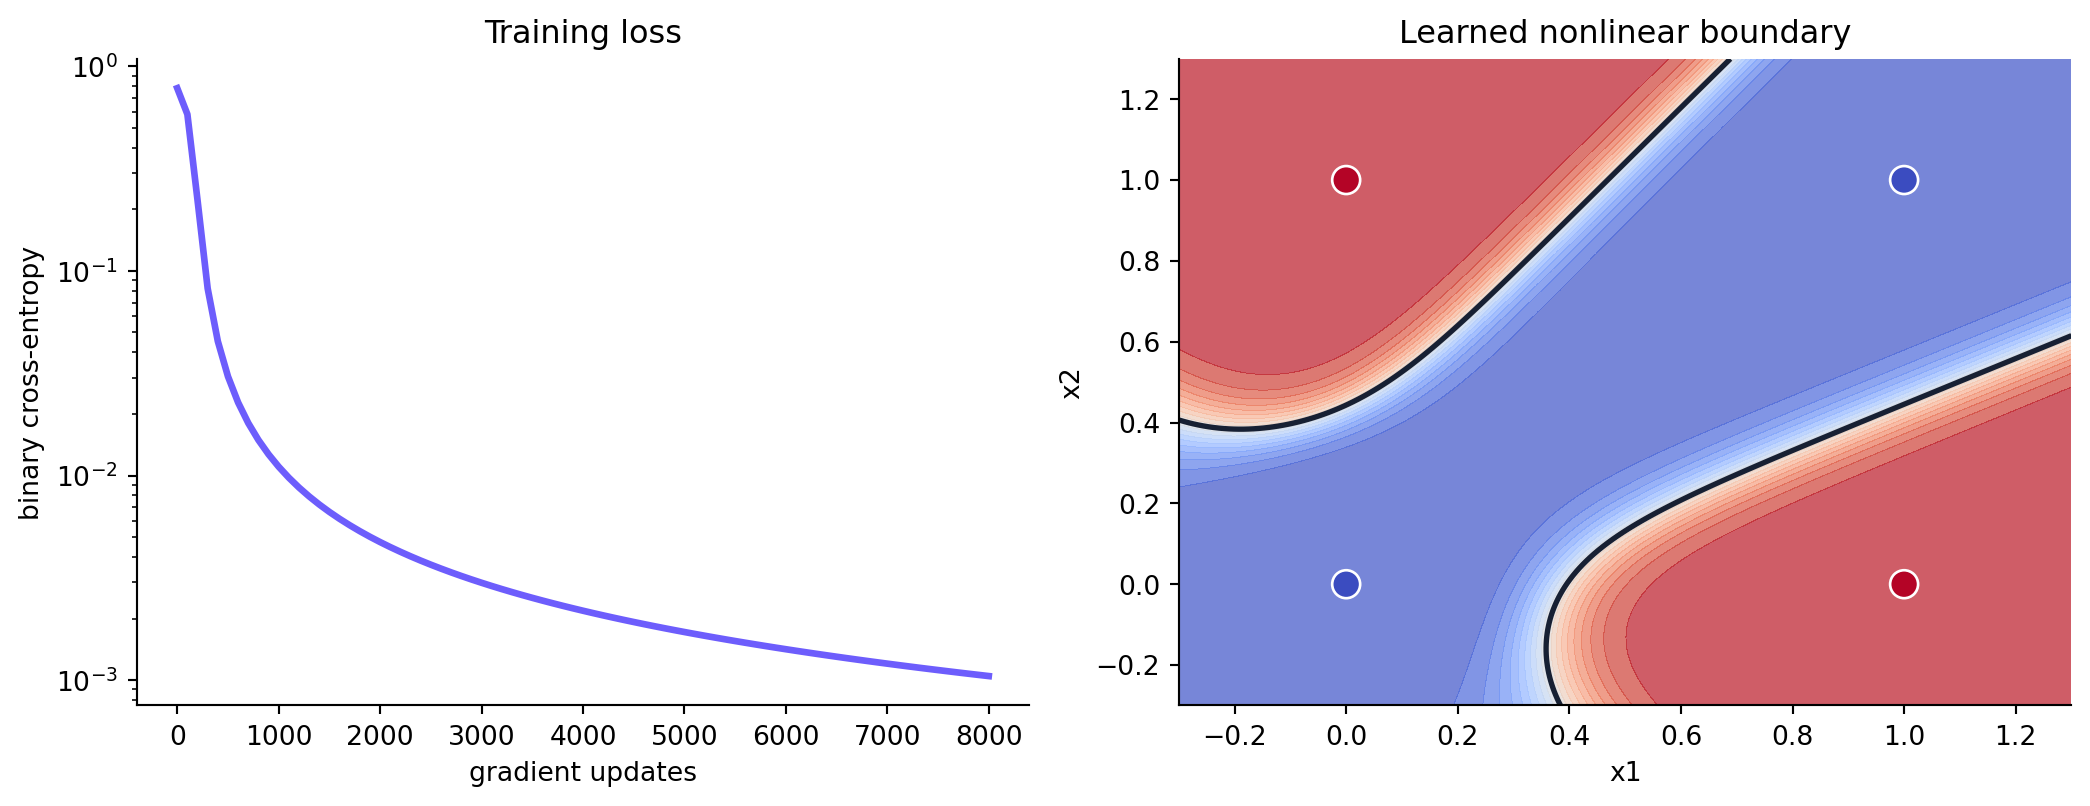

In [6]:
grid_x1, grid_x2 = np.meshgrid(np.linspace(-.3, 1.3, 180), np.linspace(-.3, 1.3, 180))
grid = np.column_stack([grid_x1.ravel(), grid_x2.ravel()])
_, grid_probability = forward(grid, W1, b1, W2, b2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(history.step, history.loss, color="#6d5dfc", linewidth=2.5)
axes[0].set(title="Training loss", xlabel="gradient updates", ylabel="binary cross-entropy")
axes[0].set_yscale("log")

contour = axes[1].contourf(grid_x1, grid_x2, grid_probability.reshape(grid_x1.shape), levels=20, cmap="coolwarm", alpha=.72)
axes[1].contour(grid_x1, grid_x2, grid_probability.reshape(grid_x1.shape), levels=[.5], colors="#172033", linewidths=2)
axes[1].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", s=110, edgecolor="white")
axes[1].set(title="Learned nonlinear boundary", xlabel="x1", ylabel="x2")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## What the hidden layer learned

Each hidden unit defines a soft linear feature, and `tanh` bends that feature into a nonlinear response. The output layer combines those responses. The network does not store an `XOR` rule symbolically; it learns a smooth surface that assigns high probability to the two positive corners.

## Common training failures

- Initializing every weight to the same value prevents hidden units from learning different features.
- Omitting the nonlinear activation makes depth ineffective.
- A very large learning rate makes loss oscillate or become non-finite.
- Evaluating only training loss says nothing about generalization. XOR is a teaching example, not a realistic validation design.
- Numerically taking `log(0)` breaks cross-entropy; probabilities need stable computation or clipping.

## Try it yourself

Change the hidden layer from four units to one, two, and eight. Repeat with several random seeds and record final loss. Then replace `tanh` with ReLU and derive the new backward step. Next: **[Language models and attention](language-models-and-attention.html)**.